<a href="https://colab.research.google.com/github/Nash2027/Driver_attention/blob/main/Driver_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Connexion au Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

print("Google Drive monté avec succès !")


Mounted at /content/drive
✅ Google Drive monté avec succès !


In [2]:
!pip install mediapipe


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 13.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled p

In [7]:
import os, shutil, random, math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# Paramètres
ORIGINAL = "/content/drive/MyDrive/imgs/train"   # <-- adapte si besoin
BINARY_DIR = "/content/binary_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 15
FINE_TUNE_AT = 120

print("Config prête.")


Config prête.


In [8]:
# Reset dataset binaire
if os.path.exists(BINARY_DIR):
    shutil.rmtree(BINARY_DIR)
os.makedirs(os.path.join(BINARY_DIR, "attentif"), exist_ok=True)
os.makedirs(os.path.join(BINARY_DIR, "distrait"), exist_ok=True)

# Rassembler chemins
att_list = [os.path.join(ORIGINAL, "c0", f) for f in os.listdir(os.path.join(ORIGINAL, "c0")) if f.lower().endswith(('.jpg','.jpeg','.png'))]
dist_list = []
for i in range(1,10):
    d = os.path.join(ORIGINAL, f"c{i}")
    if os.path.isdir(d):
        dist_list += [os.path.join(d, f) for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png'))]

print("Found", len(att_list), "attentif images")
print("Found", len(dist_list), "distrait images")

# équilibrage par downsample (min) - tu peux changer la stratégie si tu veux upsample
min_count = min(len(att_list), len(dist_list))
random.seed(42)
att_sel = random.sample(att_list, min_count)
dist_sel = random.sample(dist_list, min_count)

# Copier dans binary dataset
for i, p in enumerate(att_sel):
    shutil.copy(p, os.path.join(BINARY_DIR, "attentif", f"att_{i}.jpg"))
for i, p in enumerate(dist_sel):
    shutil.copy(p, os.path.join(BINARY_DIR, "distrait", f"dist_{i}.jpg"))

print("Binary dataset created:", BINARY_DIR)
print(" - attentif:", len(os.listdir(os.path.join(BINARY_DIR,"attentif"))))
print(" - distrait:", len(os.listdir(os.path.join(BINARY_DIR,"distrait"))))


Found 1267 attentif images
Found 10217 distrait images
✅ Binary dataset created: /content/binary_dataset
 - attentif: 1267
 - distrait: 1267


In [9]:
train_ds = keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True
)

val_ds = keras.utils.image_dataset_from_directory(
    BINARY_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=True
)

print("Classes:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


Found 2534 files belonging to 2 classes.
Using 2028 files for training.
Found 2534 files belonging to 2 classes.
Using 506 files for validation.
Classes: ['attentif', 'distrait']


In [10]:
# compute class weights from counts in folders
n_att = len(os.listdir(os.path.join(BINARY_DIR,"attentif")))
n_dis = len(os.listdir(os.path.join(BINARY_DIR,"distrait")))
total = n_att + n_dis
# weight = total / (n_classes * count)
w0 = total / (2 * n_att)
w1 = total / (2 * n_dis)
class_weights = {0: w0, 1: w1}
print("Class weights:", class_weights)


Class weights: {0: 1.0, 1: 1.0}


In [11]:
# augmentation légère + preprocess_input
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
], name="data_augmentation")

# Inputs / pipeline functional API
img_input = keras.Input(shape=IMG_SIZE + (3,), name="img_input")
x = data_augmentation(img_input)
x = preprocess_input(x)

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False  # warmup: freeze base

x = base_model(x, training=False)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid", name="out")(x)

model = keras.Model(inputs=img_input, outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
from IPython.display import clear_output

class PlotLearning(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.acc = []; self.val_acc = []; self.loss = []; self.val_loss = []
    def on_epoch_end(self, epoch, logs=None):
        self.acc.append(logs.get("accuracy"))
        self.val_acc.append(logs.get("val_accuracy"))
        self.loss.append(logs.get("loss"))
        self.val_loss.append(logs.get("val_loss"))
        clear_output(wait=True)
        plt.figure(figsize=(14,5))
        plt.subplot(1,2,1); plt.plot(self.acc, label="train"); plt.plot(self.val_acc, label="val"); plt.legend(); plt.title("Accuracy")
        plt.subplot(1,2,2); plt.plot(self.loss, label="train"); plt.plot(self.val_loss, label="val"); plt.legend(); plt.title("Loss")
        plt.show()

class EpochProgress(keras.callbacks.Callback):
    def __init__(self, total_epochs): super().__init__(); self.total_epochs = total_epochs
    def on_epoch_begin(self, epoch, logs=None):
        clear_output(wait=True)
        cur = epoch+1; total=self.total_epochs
        bar_length=30
        filled = int(bar_length * (cur/total))
        bar = "█"*filled + "-"*(bar_length-filled)
        print(f"Epoch {cur}/{total}  [{bar}]  remaining: {total-cur}")

plot_cb = PlotLearning()
epoch_progress = EpochProgress(WARMUP_EPOCHS + FINETUNE_EPOCHS)
earlystop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)

all_callbacks = [plot_cb, epoch_progress, earlystop]


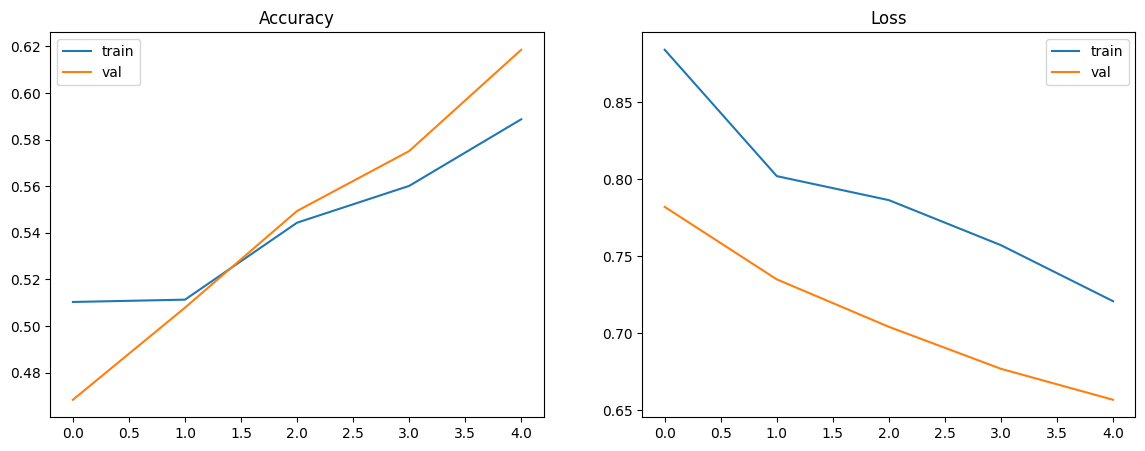

64/64 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.5528 - loss: 0.7428 - val_accuracy: 0.6186 - val_loss: 0.6569
Restoring model weights from the end of the best epoch: 5.


In [13]:
print("=== Phase 1 : WARMUP ===")
base_model.trainable = False  # geler tout

history_warm = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    class_weight=class_weights,
    verbose=1
)


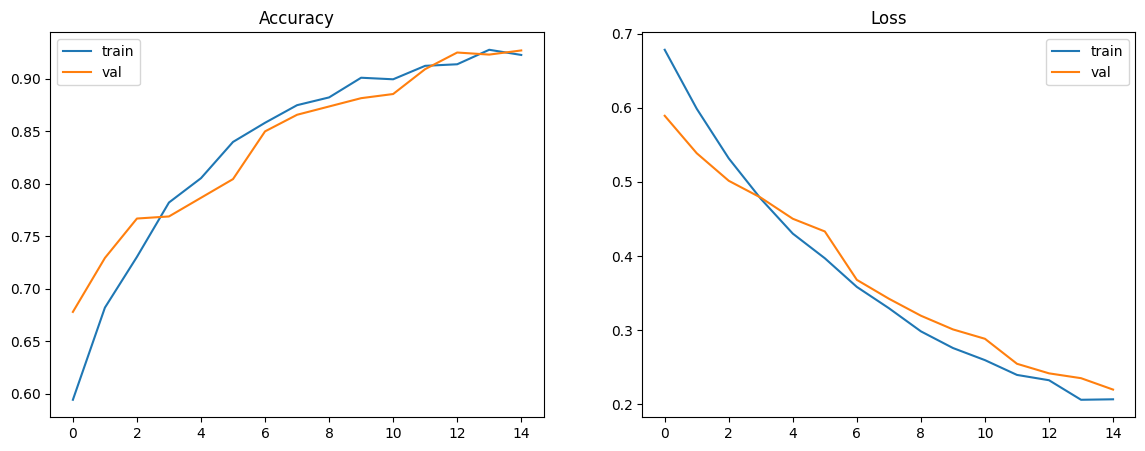

64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.9292 - loss: 0.1909 - val_accuracy: 0.9269 - val_loss: 0.2198
Restoring model weights from the end of the best epoch: 15.


In [14]:
# Unfreeze from FINE_TUNE_AT and recompile with smaller lr
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=all_callbacks,
    class_weight=class_weights,
    verbose=1
)


In [19]:
model_path = "/content/drive/MyDrive/driver_attention_model_with_mp.keras"
model.save(model_path)
print("Modèle sauvegardé :", model_path)


Modèle sauvegardé : /content/drive/MyDrive/driver_attention_model_with_mp.keras


📤 Upload one or more images to test (from local PC)...


Saving img_56.jpg to img_56.jpg
Saving img_63.jpg to img_63.jpg
Saving img_118.jpg to img_118.jpg
Saving img_120.jpg to img_120.jpg
Saving img_138.jpg to img_138.jpg
Saving img_274.jpg to img_274.jpg
Saving img_383.jpg to img_383.jpg
Saving img_443.jpg to img_443.jpg
Saving img_444.jpg to img_444.jpg
Saving img_457.jpg to img_457.jpg
Saving img_464.jpg to img_464.jpg
Saving img_573.jpg to img_573.jpg


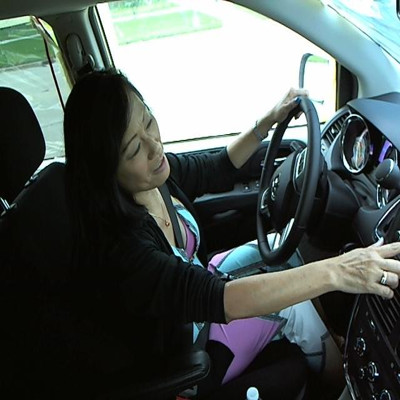

Image: img_56.jpg
Model prob (distrait): 0.3787
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



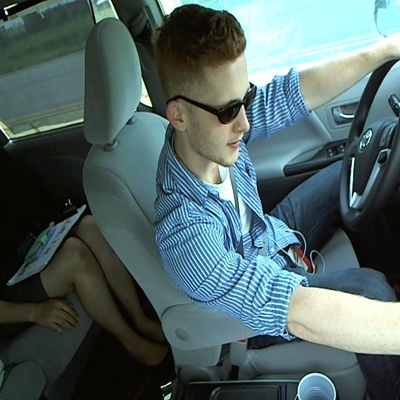

Image: img_63.jpg
Model prob (distrait): 0.4132
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



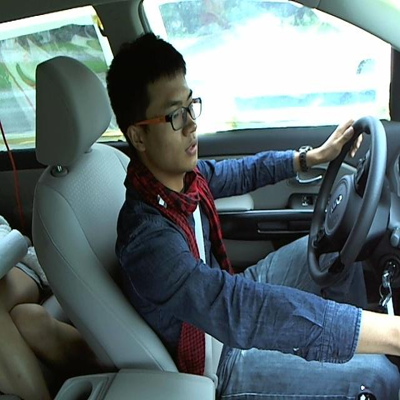

Image: img_118.jpg
Model prob (distrait): 0.3741
Model label: attentif
MP - face detected: True | hands count: 0
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



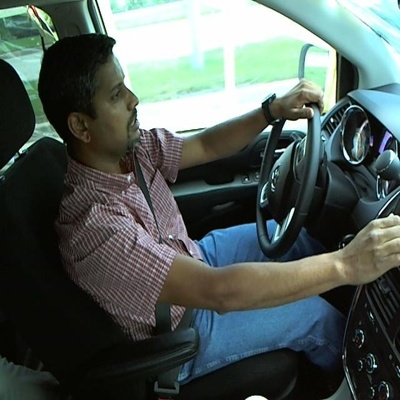

Image: img_120.jpg
Model prob (distrait): 0.4082
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



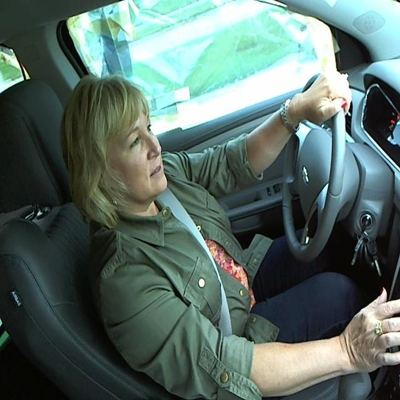

Image: img_138.jpg
Model prob (distrait): 0.4044
Model label: attentif
MP - face detected: True | hands count: 2
Corrected: attentif (prob 0.40)
---------------------------------------------------



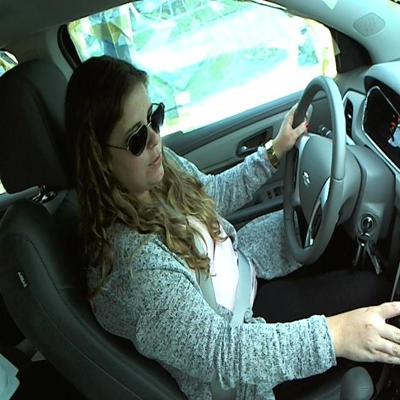

Image: img_274.jpg
Model prob (distrait): 0.4140
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



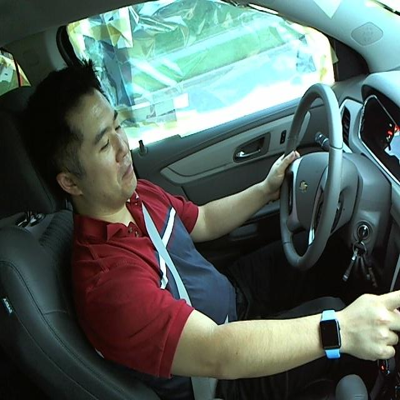

Image: img_383.jpg
Model prob (distrait): 0.3815
Model label: attentif
MP - face detected: True | hands count: 2
Corrected: attentif (prob 0.38)
---------------------------------------------------



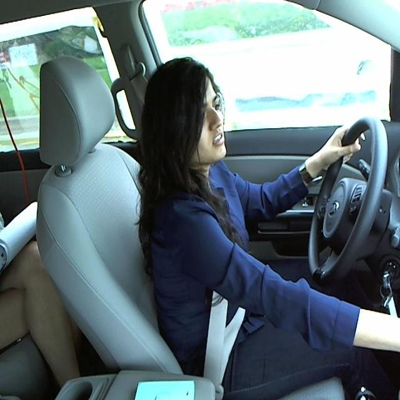

Image: img_443.jpg
Model prob (distrait): 0.3376
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



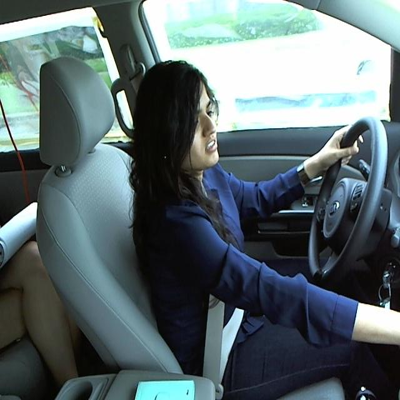

Image: img_444.jpg
Model prob (distrait): 0.3409
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



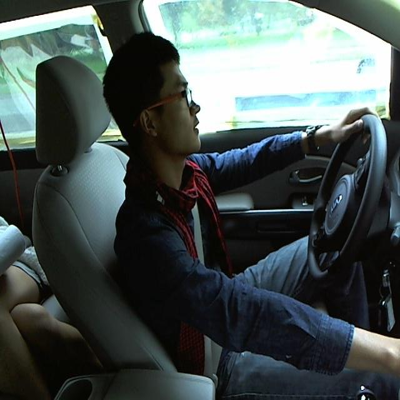

Image: img_457.jpg
Model prob (distrait): 0.3658
Model label: attentif
MP - face detected: True | hands count: 0
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



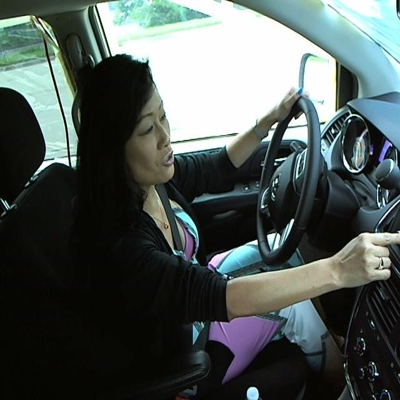

Image: img_464.jpg
Model prob (distrait): 0.3945
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



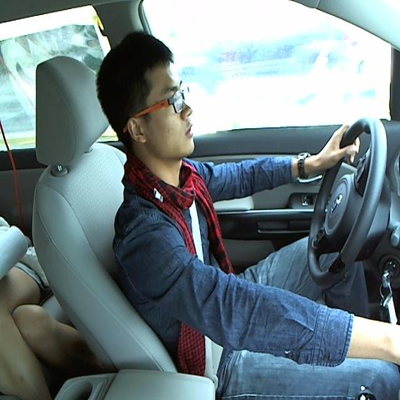

Image: img_573.jpg
Model prob (distrait): 0.3671
Model label: attentif
MP - face detected: True | hands count: 1
Corrected: distrait (MP override) (prob 0.75)
---------------------------------------------------



In [18]:
# Chargement model + mediapipe setup
import mediapipe as mp
from google.colab import files
from PIL import Image
import io

model = keras.models.load_model(model_path)
mp_hands = mp.solutions.hands
mp_face = mp.solutions.face_detection

hands_detector = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.4)
face_detector = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.4)

def mediapipe_check(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    face_res = face_detector.process(rgb)
    hands_res = hands_detector.process(rgb)
    has_face = face_res.detections is not None
    n_hands = 0 if hands_res.multi_hand_landmarks is None else len(hands_res.multi_hand_landmarks)
    return has_face, n_hands

def predict_with_correction(img_pil):
    # prepare image
    img = img_pil.convert("RGB").resize(IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr_proc = preprocess_input(np.expand_dims(arr, 0))
    prob = float(model.predict(arr_proc, verbose=0)[0][0])  # prob distrait (sigmoid)
    model_label = "distrait" if prob > 0.5 else "attentif"

    # mediapipe check on original resolution (convert PIL -> BGR)
    img_cv = cv2.cvtColor(np.array(img_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    has_face, n_hands = mediapipe_check(img_cv)

    # If model says attentif but MP sees no face or less than 2 hands => force distract
    corrected_label = model_label
    corrected_prob = prob
    if model_label == "attentif" and (not has_face or n_hands < 2):
        corrected_label = "distrait (MP override)"
        # boost probability to indicate override
        corrected_prob = max(prob, 0.75)

    # return results
    return {
        "model_prob_distrait": prob,
        "model_label": model_label,
        "has_face": has_face,
        "n_hands": n_hands,
        "corrected_label": corrected_label,
        "corrected_prob": corrected_prob
    }

# Test Image
print("📤 Upload one or more images to test (from local PC)...")
uploaded = files.upload()
for name, data in uploaded.items():
    img = Image.open(io.BytesIO(data))
    res = predict_with_correction(img)
    display(img.resize((400,400)))
    print("Image:", name)
    print("Model prob (distrait): {:.4f}".format(res["model_prob_distrait"]))
    print("Model label:", res["model_label"])
    print("MP - face detected:", res["has_face"], "| hands count:", res["n_hands"])
    print("Corrected:", res["corrected_label"], "(prob {:.2f})".format(res["corrected_prob"]))
    print("---------------------------------------------------\n")


In [ ]:
#BONUS Test sur tous les fichiers du dataset
TEST_FOLDER = "/content/binary_dataset/distrait"  # à adapter si besoin
import glob
results = []
for p in glob.glob(os.path.join(TEST_FOLDER, "*.jpg"))[:200]:
    img_pil = Image.open(p)
    r = predict_with_correction(img_pil)
    results.append((p, r["model_prob_distrait"], r["model_label"], r["has_face"], r["n_hands"], r["corrected_label"]))

# Quick stats
n = len(results)
n_model_distr = sum(1 for _p,prob,lab,face,hands,cor in results if prob>0.5)
n_corrected = sum(1 for _p,prob,lab,face,hands,cor in results if "override" in cor)
print(f"Tested {n} images. model predicted distract on {n_model_distr}/{n}. Corrected by MP on {n_corrected}.")
